# From tilt movies to a tomogram: the whole teamtomo stack end to end

This notebook simulates a **realistically flawed** cryo-ET tilt series and then processes it
back into a tomogram, scoring every step against ground truth we injected ourselves.

**Phase 1 — simulate.** Pack 6DRV apoferritin plus gold fiducials into an ice slab, build a
Shang–Sigworth solvated electrostatic potential, and record a **dose-fractionated movie at every
tilt**: 41 tilts from −60° to +60° in 3° steps, each a 6-frame movie of 0.5 e⁻/Å² (3 e⁻/Å² per
tilt). Each frame gets its own beam-induced motion, its own accumulated radiation damage, and its
own Poisson noise. Between tilts the stage takes a random walk, so the series is misaligned.

**Phase 2 — motion correct.** `torch-motion-correction` estimates global and local motion per
movie; `torch-fourier-filter` dose-weights the frames into one sum per tilt.

**Phase 3 — align and reconstruct.** `torch-tiltxcorr` finds the per-tilt shifts,
`torch-refine-tilt-axis-angle` recovers the tilt-axis angle from a deliberately wrong starting
guess, and `torch-reconstruct-tomogram` produces the tomogram.

**Phase 4 — scale up.** The same functions on a bigger box with more particles.

Because every defect has a known value, each stage gets a number rather than a vibe. Several of
those numbers are surprising, and the notebook says so where they are.

### Packages exercised

| Package | Used for |
|---|---|
| `torch-structure-manipulation`, `mmdf` | load and pose 6DRV |
| `torch-calculate-electrostatic-potential` | solvated ESP of protein + gold |
| `torch-scattering` | multislice exit wave |
| `torch-simulate-image` | CTF, dose weighting, fluence scaling, Poisson |
| `torch-fourier-shift` | exact rigid stage shifts |
| `torch-motion-correction` | motion estimation, correction, deformation fields |
| `torch-fourier-filter` | dose weighting, bandpass, low-pass |
| `torch-ctf` | CTF for correction |
| `torch-tiltxcorr` | coarse tilt-series alignment |
| `torch-refine-tilt-axis-angle` | tilt-axis angle refinement |
| `torch-tilt-series`, `torch-reconstruct-tomogram` | geometry and reconstruction |
| `torch-fourier-shell-correlation` | scoring against ground truth |

> **CTF estimation is not included.** `torch-ctf-estimation` is not yet in the monorepo (it
> lands with PR #115); this notebook uses the known defocus and marks the spot where
> `estimate_ctf` will slot in.

In [1]:
from __future__ import annotations

import functools
import tempfile
import warnings
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import mmdf
import mrcfile
import numpy as np
import pandas as pd
import torch
import tqdm
from torch_calculate_electrostatic_potential import (
    GridConfig,
    default_sublattice_radius,
    solvated_potential_from_structure_3d,
)
from torch_ctf import calculate_ctf_2d
from torch_fourier_filter.bandpass import low_pass_filter
from torch_fourier_filter.dose_weight import dose_weight_movie
from torch_fourier_shell_correlation import fsc
from torch_fourier_shift import fourier_shift_image_2d
from torch_motion_correction import (
    DeformationField,
    FourierFilterConfig,
    OptimizationConfig,
    PatchSamplingConfig,
    correct_motion,
    estimate_global_motion,
    estimate_local_motion,
)
from torch_reconstruct_tomogram import reconstruct_tomogram
from torch_refine_tilt_axis_angle import refine_tilt_axis_angle
from torch_scattering import multislice
from torch_structure_manipulation import (
    AtomicStructure,
    annotate_bonding_environments,
    apply_rotation,
    apply_translation,
    center_structure,
    create_rotation_matrix_from_euler,
)
from torch_tilt_series import TiltSeries
from torch_tiltxcorr import tiltxcorr

from torch_simulate_image import (
    CtfConfig,
    DoseWeightConfig,
    FluenceConfig,
    MicrographSimulationConfig,
    PoissonConfig,
    apply_ctf_to_exit_wave,
    exit_wave_to_intensity,
    simulate_micrograph_from_intensity,
    tilt_volume,
)

# the motion-correction optimiser draws a tqdm bar per tilt; 41 of them would bury
# the output of this notebook
tqdm.tqdm.__init__ = functools.partialmethod(tqdm.tqdm.__init__, disable=True)

# most protein atoms have no tabulated *bonded* Peng parameters and fall back to
# elemental ones, which is the intended behaviour of bonded_fallback="elemental"
warnings.filterwarnings(
    "ignore", message="unsupported bonded scattering parameters", category=UserWarning
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__} on {DEVICE}")

torch 2.9.1+cu128 on cuda


## Parameters

Everything lives in one `Config`, so Phase 4 re-runs the identical functions on a bigger box by
changing two fields.

In [2]:
@dataclass
class Config:
    """All knobs for one end-to-end run."""

    # ---- specimen ----
    pixel_size: float = 4.0  # A/px
    grid_shape: tuple[int, int, int] = (256, 256, 256)  # (Z, Y, X) voxels
    n_particles: int = 5
    particle_radius_a: float = 70.0  # exclusion radius for packing
    n_fiducials: int = 32  # gold beads
    fiducial_radius_a: float = 25.0  # 5 nm beads
    slab_half_thickness_a: float = 40.0  # particle centres stay within +/- this in Z

    # ---- optics ----
    voltage_kv: float = 300.0
    ice_potential_v: float = 3.6
    probe_radius: float = 1.4
    defocus_um: float = 5.0
    spherical_aberration_mm: float = 2.7
    amplitude_contrast: float = 0.07

    # ---- acquisition ----
    tilt_min: float = -60.0
    tilt_max: float = 60.0
    tilt_step: float = 3.0
    # in-plane angle between the microscope tilt axis and the detector rows,
    # measured from +y -- the quantity an mdoc records
    detector_rotation_deg: float = -5.0
    fluence_per_tilt: float = 3.0  # e-/A^2 per tilt, split over frames
    n_frames: int = 6

    # ---- ground-truth motion, in pixels ----
    intra_movie_global_px: float = 2.0  # rigid drift over one movie
    local_motion_px: float = 1.5  # outward motion of the 4 patches
    stage_step_px: float = 0.5  # per-tilt random-walk step

    # ---- processing ----
    mc_iterations: int = 200
    mc_learning_rate: float = 0.02
    mc_patch: int = 64
    mc_frequency_range: tuple[float, float] = (300.0, 20.0)
    ctf_wiener_eps: float = 0.1
    recon_sidelength: int = 64
    # reconstruct_tomogram does `chunk_size = batch_size or n_patches`, i.e. it
    # allocates every patch at once by default. At 512^3 that is 216 patches and
    # a 17 GiB single allocation; batching keeps the peak near 6 GiB.
    recon_batch_size: int = 8

    seed: int = 0
    device: torch.device = field(default_factory=lambda: DEVICE)

    @property
    def tilt_angles(self) -> torch.Tensor:
        """The tilt scheme, in degrees."""
        n = round((self.tilt_max - self.tilt_min) / self.tilt_step) + 1
        return torch.linspace(self.tilt_min, self.tilt_max, n)

    @property
    def dose_per_frame(self) -> float:
        """Fluence per movie frame, in e-/A^2."""
        return self.fluence_per_tilt / self.n_frames

    @property
    def image_shape(self) -> tuple[int, int]:
        """Detector shape (h, w)."""
        return self.grid_shape[1], self.grid_shape[2]

    @property
    def crowther_resolution_a(self) -> float:
        """Crowther limit: d = pi * D / N, for D the field width and N the view count."""
        return np.pi * self.grid_shape[2] * self.pixel_size / len(self.tilt_angles)


cfg = Config()
print(
    f"grid {cfg.grid_shape} at {cfg.pixel_size} A/px "
    f"= {cfg.grid_shape[2] * cfg.pixel_size:.0f} A field"
)
print(
    f"{len(cfg.tilt_angles)} tilts, {cfg.tilt_min:+.0f}..{cfg.tilt_max:+.0f} deg, "
    f"step {cfg.tilt_step:.0f} deg, detector rotated "
    f"{cfg.detector_rotation_deg:+.0f} deg from the tilt axis"
)
print(
    f"{cfg.n_frames} frames/tilt at {cfg.dose_per_frame} e-/A^2 "
    f"= {cfg.fluence_per_tilt} e-/A^2 per tilt, "
    f"{cfg.fluence_per_tilt * len(cfg.tilt_angles):.0f} e-/A^2 total"
)
print(f"angular sampling (Crowther) limit: {cfg.crowther_resolution_a:.0f} A")

grid (256, 256, 256) at 4.0 A/px = 1024 A field
41 tilts, -60..+60 deg, step 3 deg, detector rotated -5 deg from the tilt axis
6 frames/tilt at 0.5 e-/A^2 = 3.0 e-/A^2 per tilt, 123 e-/A^2 total
angular sampling (Crowther) limit: 78 A


## 1a. The specimen: apoferritin *and* gold fiducials

Gold beads are not decoration. Without them this simulation is impossible to motion-correct, and
the measurement that shows why is a few cells below — it was the single most consequential finding
in building this notebook.

The beads are built as **real Au atoms** on an FCC lattice at bulk gold density (19.3 g/cm³), so
they go through exactly the same `solvated_potential_from_structure_3d` path as the protein: Peng
scattering factors (gold's amplitude is ~10× carbon's) and proper solvent displacement by van der
Waals radius. No blobs stamped into the potential.

Particle centres are confined to a thin slab in Z. That matters — see the thickness measurement in
the alignment section.

In [3]:
def sample_slab_centers(cfg: Config, rng: np.random.Generator) -> np.ndarray:
    """Rejection-sample non-overlapping particle centres inside a Z slab.

    The grid is (Z, Y, X), so in-plane extent comes from grid_shape[2]/[1] and the
    slab thickness from grid_shape[0].
    """
    r = cfg.particle_radius_a
    half = [(n - 1) * cfg.pixel_size / 2 for n in cfg.grid_shape]  # z, y, x
    x_lim, y_lim = half[2] - r, half[1] - r
    z_lim = min(cfg.slab_half_thickness_a, half[0] - r)
    if min(x_lim, y_lim, z_lim) <= 0:
        raise RuntimeError(
            f"particle_radius_a={r} A leaves no room in {cfg.grid_shape}"
        )

    centers: list[np.ndarray] = []
    for _ in range(1_000_000):
        if len(centers) >= cfg.n_particles:
            break
        cand = np.array(
            [
                rng.uniform(-x_lim, x_lim),
                rng.uniform(-y_lim, y_lim),
                rng.uniform(-z_lim, z_lim),
            ]
        )
        if all(np.linalg.norm(cand - c) >= 2 * r for c in centers):
            centers.append(cand)
    if len(centers) < cfg.n_particles:
        raise RuntimeError(
            f"only placed {len(centers)}/{cfg.n_particles} particles; lower n_particles "
            f"or particle_radius_a, or thicken the slab"
        )
    return np.asarray(centers)


# gold: FCC, a = 4.078 A, 4 atoms/cell -> 4 / 4.078**3 = 0.059 atoms/A^3 = 19.3 g/cm3
GOLD_LATTICE_A = 4.078
_FCC_BASIS = np.array(
    [[0, 0, 0], [0.5, 0.5, 0], [0.5, 0, 0.5], [0, 0.5, 0.5]], dtype=float
)


def gold_bead_atoms(center_xyz: np.ndarray, radius_a: float) -> pd.DataFrame:
    """One solid gold bead as Au atoms on an FCC lattice, at bulk density."""
    n_cells = int(np.ceil(2 * radius_a / GOLD_LATTICE_A)) + 1
    idx = np.arange(-n_cells, n_cells + 1)
    cells = np.stack(np.meshgrid(idx, idx, idx, indexing="ij"), -1).reshape(-1, 3)
    xyz = ((cells[:, None, :] + _FCC_BASIS[None]) * GOLD_LATTICE_A).reshape(-1, 3)
    xyz = xyz[np.linalg.norm(xyz, axis=1) <= radius_a] + center_xyz

    n = len(xyz)
    return pd.DataFrame(
        {
            "model": np.ones(n, dtype=np.int64),
            "chain": "AU",
            "residue": "AU",
            "residue_id": np.arange(1, n + 1, dtype=np.int64),
            "atom": "AU",
            "element": "AU",
            "atomic_number": np.full(n, 79, dtype=np.int64),
            "atomic_weight": np.full(n, 196.966569),
            "covalent_radius": np.full(n, 1.36),
            "van_der_waals_radius": np.full(n, 1.66),
            "heteroatom_flag": "H",
            "x": xyz[:, 0],
            "y": xyz[:, 1],
            "z": xyz[:, 2],
            "charge": np.zeros(n, dtype=np.int64),
            "occupancy": np.ones(n),
            "b_isotropic": np.full(n, 20.0),
            "bonded_environments": None,  # -> elemental Peng parameters for Au
            "molecule_type": "other",
        }
    )


def sample_fiducial_centers(
    cfg: Config, rng: np.random.Generator, particle_centers: np.ndarray
) -> np.ndarray:
    """Place gold beads in the slab, clear of each other and of the particles."""
    if cfg.n_fiducials == 0:
        return np.zeros((0, 3))
    r = cfg.fiducial_radius_a
    half = [(n - 1) * cfg.pixel_size / 2 for n in cfg.grid_shape]
    x_lim, y_lim = half[2] - r - 8.0, half[1] - r - 8.0

    centers: list[np.ndarray] = []
    for _ in range(1_000_000):
        if len(centers) >= cfg.n_fiducials:
            break
        cand = np.array(
            [
                rng.uniform(-x_lim, x_lim),
                rng.uniform(-y_lim, y_lim),
                rng.uniform(-cfg.slab_half_thickness_a, cfg.slab_half_thickness_a),
            ]
        )
        if any(
            np.linalg.norm(cand - c) < cfg.particle_radius_a + r
            for c in particle_centers
        ):
            continue
        if all(np.linalg.norm(cand - c) >= 3 * r for c in centers):
            centers.append(cand)
    if len(centers) < cfg.n_fiducials:
        raise RuntimeError(
            f"only placed {len(centers)}/{cfg.n_fiducials} gold fiducials"
        )
    return np.asarray(centers)

In [4]:
def build_specimen(cfg: Config, verbose: bool = True):
    """Pack 6DRV copies plus gold fiducials into a slab; return the solvated ESP.

    Returns (volume, grid, particle_centers_xyz, gold_centers_xyz).
    """
    rng = np.random.default_rng(cfg.seed)

    atoms = mmdf.read("pdb:6drv")
    template = annotate_bonding_environments(atoms, include_hydrogens=False)
    template = center_structure(template, center_point=(0.0, 0.0, 0.0), zyx=False)

    centers = sample_slab_centers(cfg, rng)
    placed = []
    for c in centers:
        angles = torch.tensor(rng.uniform(0.0, 360.0, size=3), dtype=torch.float32)
        rot = create_rotation_matrix_from_euler(angles, order="ZYZ", degrees=True)
        mol = apply_rotation(template, rot, zyx=False)
        placed.append(apply_translation(mol, tuple(c.tolist()), zyx=False))

    gold_centers = sample_fiducial_centers(cfg, rng, centers)
    for gc in gold_centers:
        placed.append(gold_bead_atoms(gc, cfg.fiducial_radius_a))

    all_atoms = pd.concat(placed, ignore_index=True)
    n_gold = int((all_atoms["atomic_number"] == 79).sum())
    if verbose:
        print(
            f"{len(all_atoms):,} atoms: {len(all_atoms) - n_gold:,} protein in "
            f"{len(centers)} particles, {n_gold:,} gold in {len(gold_centers)} beads"
        )

    structure = AtomicStructure.from_dataframe(all_atoms, device=cfg.device)
    grid = GridConfig.from_grid_shape_and_voxel_size(
        grid_shape=cfg.grid_shape,
        voxel_size=(cfg.pixel_size,) * 3,
        center_zyx=(0.0, 0.0, 0.0),
        sublattice_radius=default_sublattice_radius(cfg.pixel_size),
        equal_length=False,
        device=cfg.device,
    )
    if verbose:
        print("building Shang-Sigworth solvated ESP (the slow step) ...")
    volume = solvated_potential_from_structure_3d(
        structure,
        grid,
        model_water_potential=True,
        solvent_model="shang_sigworth",
        ice_potential_V=cfg.ice_potential_v,
        probe_radius=cfg.probe_radius,
        scattering_factors="peng_bonded",
        bonded_fallback="elemental",
    )
    if verbose:
        print(
            f"ESP {tuple(volume.shape)}: mean {volume.mean():.2f} V "
            f"(bulk ice {cfg.ice_potential_v} V), max {volume.max():.1f} V (gold)"
        )
    return volume, grid, centers, gold_centers


volume, grid, centers, gold_centers = build_specimen(cfg)

290,040 atoms: 164,440 protein in 5 particles, 125,600 gold in 32 beads


building Shang-Sigworth solvated ESP (the slow step) ...


ESP (256, 256, 256): mean 3.65 V (bulk ice 3.6 V), max 30.4 V (gold)


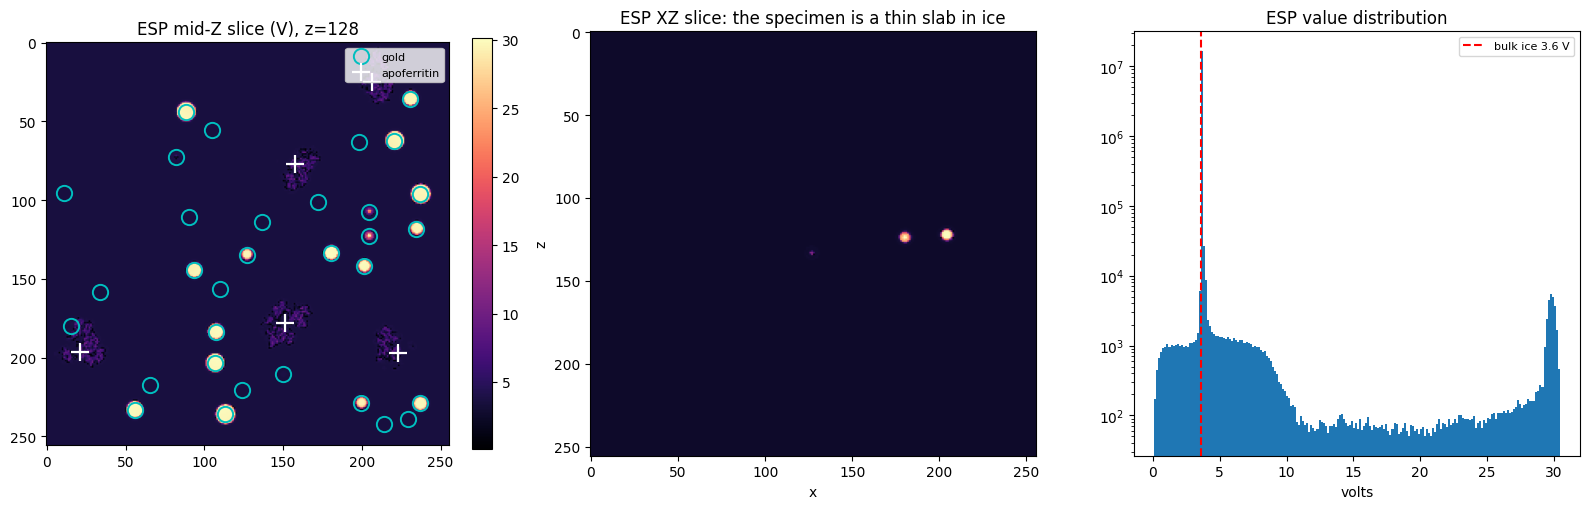

In [5]:
def to_voxel_zyx(xyz_a: np.ndarray, shape: tuple[int, int, int], pixel_size: float):
    """Convert xyz Angstrom positions (origin at volume centre) to zyx voxel indices.

    The ESP grid is centred on the origin, so the centre voxel is at (n - 1) / 2.
    """
    centre = np.array([(n - 1) / 2 for n in shape])
    return (
        np.stack([xyz_a[:, 2], xyz_a[:, 1], xyz_a[:, 0]], axis=-1) / pixel_size + centre
    )


p_vox = to_voxel_zyx(centers, cfg.grid_shape, cfg.pixel_size)
g_vox = to_voxel_zyx(gold_centers, cfg.grid_shape, cfg.pixel_size)

mid = cfg.grid_shape[0] // 2
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
sl = volume[mid].detach().cpu().numpy()
im = axes[0].imshow(sl, cmap="magma")
axes[0].plot(g_vox[:, 2], g_vox[:, 1], "co", mfc="none", ms=11, mew=1.4, label="gold")
axes[0].plot(p_vox[:, 2], p_vox[:, 1], "w+", ms=13, mew=1.6, label="apoferritin")
axes[0].set_title(f"ESP mid-Z slice (V), z={mid}")
axes[0].legend(fontsize=8, loc="upper right")
plt.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].imshow(
    volume[:, cfg.grid_shape[1] // 2].detach().cpu().numpy(),
    cmap="magma",
    aspect="auto",
)
axes[1].set_title("ESP XZ slice: the specimen is a thin slab in ice")
axes[1].set_xlabel("x")
axes[1].set_ylabel("z")

axes[2].hist(volume.detach().cpu().numpy().ravel(), bins=200, log=True)
axes[2].axvline(cfg.ice_potential_v, color="r", ls="--", label="bulk ice 3.6 V")
axes[2].set_title("ESP value distribution")
axes[2].set_xlabel("volts")
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 1b. Ground-truth motion

Three components, all in Ångstroms, and deliberately applied by **two different mechanisms**:

| Component | Spatially | Over the movie | Amplitude | Applied with |
|---|---|---|---|---|
| Intra-movie drift | constant | ramps up | 2 px | `DeformationField` |
| Local patch motion | 4 quadrants pointing **outward** | ramps up | 1.5 px | `DeformationField` |
| Per-tilt stage offset | constant | constant | random walk | `fourier_shift_image_2d` |

The first two go into a `DeformationField` of shape `(2, n_frames, 2, 2)` — the `2 x 2` control
grid *is* the four patches, and the leading axis is `(y, x)` shifts in Å.

The stage offset is deliberately kept out of the deformation field for two reasons.

1. **It is unobservable to motion correction by construction.** Both `estimate_local_motion` and
   `estimate_motion_cross_correlation_patches` mean-subtract their output field, so a component
   constant in space *and* time cannot be recovered — it survives into the summed image as
   tilt-series misalignment, which is exactly the signal `tiltxcorr` exists to remove. That split
   is what makes Phase 2 and Phase 3 test genuinely different things.
2. **It is a rigid shift, so it can be applied exactly.** Measured round-trip error:
   `fourier_shift_image_2d` 3.0e-07 rms versus 4.6e-02 for the bicubic resampler in
   `correct_motion`. Keeping the injected misalignment exact means the Phase 3 score measures
   `tiltxcorr`, not interpolation.

The walk is anchored to zero at the 0° tilt, matching `tiltxcorr`'s own convention of
accumulating outward from the least-tilted image.

In [6]:
def make_motion_model(cfg: Config) -> tuple[list[DeformationField], torch.Tensor]:
    """Per-tilt intra-movie deformation fields, plus the rigid stage random walk.

    Returns (fields, stage_shifts_px) where fields[i].data is (2, n_frames, 2, 2) in
    Angstroms and stage_shifts_px is (n_tilts, 2) in pixels.
    """
    g = torch.Generator().manual_seed(cfg.seed + 1)
    tilt_angles = cfg.tilt_angles
    n_tilts, nt, px = len(tilt_angles), cfg.n_frames, cfg.pixel_size

    # frame 0 has no accumulated motion, the last frame has all of it
    ramp = torch.linspace(0.0, 1.0, nt)

    # 2x2 control grid = 4 patches, unit vectors pointing radially outward
    s = 1.0 / np.sqrt(2.0)
    sign_y = torch.tensor([[-1.0, -1.0], [1.0, 1.0]]) * s
    sign_x = torch.tensor([[-1.0, 1.0], [-1.0, 1.0]]) * s

    fields: list[DeformationField] = []
    for _ in range(n_tilts):
        theta = torch.rand((), generator=g) * 2 * np.pi
        drift = torch.tensor([torch.sin(theta), torch.cos(theta)])  # random direction

        data = torch.zeros(2, nt, 2, 2)
        data[0] += ramp[:, None, None] * sign_y * cfg.local_motion_px * px
        data[1] += ramp[:, None, None] * sign_x * cfg.local_motion_px * px
        data[0] += (ramp * drift[0] * cfg.intra_movie_global_px * px)[:, None, None]
        data[1] += (ramp * drift[1] * cfg.intra_movie_global_px * px)[:, None, None]
        fields.append(DeformationField(data.to(cfg.device), grid_type="catmull_rom"))

    steps = torch.randn(n_tilts, 2, generator=g) * cfg.stage_step_px
    walk = torch.cumsum(steps, dim=0)
    walk = walk - walk[int(torch.argmin(tilt_angles.abs()))]  # anchor the 0 deg tilt
    return fields, walk


def apply_motion(frames, field: DeformationField, pixel_spacing: float):
    """Apply forward motion: the negation of what `correct_motion` removes."""
    return correct_motion(
        frames, DeformationField(-field.data, field.grid_type), pixel_spacing
    )


fields, stage_shifts = make_motion_model(cfg)
print(
    f"{len(fields)} deformation fields, each {tuple(fields[0].shape)} (yx, frames, 2, 2)"
)
print(
    f"stage walk spans {stage_shifts.min():+.2f} .. {stage_shifts.max():+.2f} px, "
    f"anchored at the 0 deg tilt: {stage_shifts[int(torch.argmin(cfg.tilt_angles.abs()))].tolist()}"
)

41 deformation fields, each (2, 6, 2, 2) (yx, frames, 2, 2)
stage walk spans -3.68 .. +2.96 px, anchored at the 0 deg tilt: [0.0, 0.0]


motion applied:   rms 0.3535 (probe std 1.0)
after correction: rms 0.0132  -> 26.7x reduction
round-trip OK


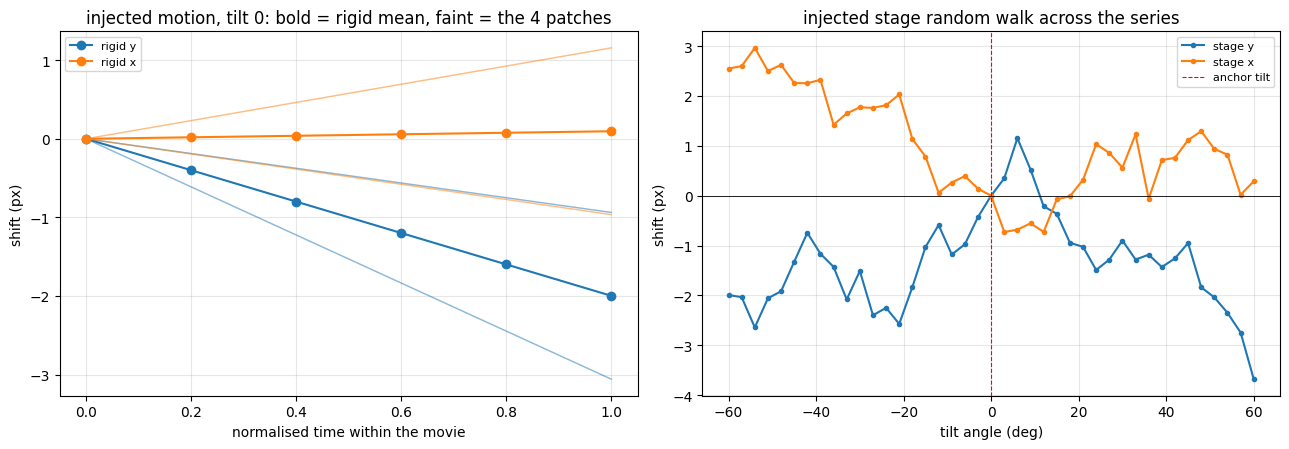

In [7]:
# Sanity check: applying forward motion then correcting it must return the original.
# `correct_motion` resamples in real space with bicubic interpolation, so this is not
# exact -- the residual is a few percent of the image std on band-limited data, and the
# outermost few pixels are corrupted outright. Judge the interior of a band-limited probe.
_probe = volume[cfg.grid_shape[0] // 2].clone()
_probe = torch.fft.irfft2(
    torch.fft.rfft2(_probe)
    * low_pass_filter(
        cutoff=cfg.pixel_size / 24.0,
        falloff=0.02,
        image_shape=cfg.image_shape,
        rfft=True,
        fftshift=False,
    ).to(_probe.device),
    s=cfg.image_shape,
)
_probe = (_probe - _probe.mean()) / _probe.std()
_frames = _probe.expand(cfg.n_frames, -1, -1).contiguous()
_moved = apply_motion(_frames, fields[0], cfg.pixel_size)
_back = correct_motion(_moved, fields[0], cfg.pixel_size)

_c = slice(8, -8)  # resampling corrupts the outermost few pixels
_applied = (_moved[:, _c, _c] - _frames[:, _c, _c]).pow(2).mean().sqrt()
_resid = (_back[:, _c, _c] - _frames[:, _c, _c]).pow(2).mean().sqrt()
print(f"motion applied:   rms {_applied:.4f} (probe std 1.0)")
print(f"after correction: rms {_resid:.4f}  -> {_applied / _resid:.1f}x reduction")
assert _resid < 0.3 * _applied, "forward/inverse motion do not round-trip"
print("round-trip OK")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
t_norm = torch.linspace(0, 1, cfg.n_frames)
for i, (lbl, c) in enumerate([("y", "tab:blue"), ("x", "tab:orange")]):
    axes[0].plot(
        t_norm,
        fields[0].data[i].mean(dim=(1, 2)).cpu() / cfg.pixel_size,
        "o-",
        color=c,
        label=f"rigid {lbl}",
    )
    for h in range(2):
        for w in range(2):
            axes[0].plot(
                t_norm,
                fields[0].data[i, :, h, w].cpu() / cfg.pixel_size,
                "-",
                color=c,
                alpha=0.3,
                lw=1,
            )
axes[0].set_xlabel("normalised time within the movie")
axes[0].set_ylabel("shift (px)")
axes[0].set_title("injected motion, tilt 0: bold = rigid mean, faint = the 4 patches")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(cfg.tilt_angles, stage_shifts[:, 0], "o-", ms=3, label="stage y")
axes[1].plot(cfg.tilt_angles, stage_shifts[:, 1], "o-", ms=3, label="stage x")
axes[1].axhline(0, color="k", lw=0.6)
axes[1].axvline(0, color="r", ls="--", lw=0.8, label="anchor tilt")
axes[1].set_xlabel("tilt angle (deg)")
axes[1].set_ylabel("shift (px)")
axes[1].set_title("injected stage random walk across the series")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 1c. Simulating one movie per tilt

Per tilt the expensive part — rotating the ESP and running multislice — happens **once**. All six
frames share that exit wave and differ only in motion, accumulated damage, and noise:

```
rotate ESP -> multislice -> CTF -> |psi|^2  ... once per tilt
   -> rigid stage shift (exact, Fourier)
   -> forward motion (deformation field)
   -> per frame: dose weight -> fluence scale -> Poisson   ... six times
```

Two details in that last line are easy to get wrong.

**Radiation damage uses `DoseWeightConfig`, not `EnvelopeConfig`.** `apply_dose_weight` uses
`0.5 * (dose_start + dose_end)`, i.e. the frame's mid-point cumulative dose, and it reads that
dose independently of `FluenceConfig`. `EnvelopeConfig(dose_envelope=True)` cannot express this:
it hard-wires the envelope's fluence to `FluenceConfig.dose_e_per_A2`, which here must stay at
0.5 for the *count* scaling. Damage accumulates across frames; exposure per frame does not.

**Poisson noise needs one persistent generator.** `PoissonConfig(deterministic=True)` builds a
freshly seeded generator on *every call*, which would give all 246 frames byte-identical noise.
Passing our own `torch.Generator` instead gives independent noise per frame *and* keeps the whole
notebook reproducible from one seed. Verified below.

In [8]:
def frame_config(cfg: Config, frame_index: int) -> MicrographSimulationConfig:
    """Detector-side config for one frame: cumulative damage, this frame's dose, Poisson."""
    d = cfg.dose_per_frame
    return MicrographSimulationConfig(
        pixel_size=cfg.pixel_size,
        # the CTF is already applied to the exit wave; voltage is still sourced here
        ctf=CtfConfig(
            defocus_um=cfg.defocus_um, voltage_kv=cfg.voltage_kv, apply=False
        ),
        dose_weight=DoseWeightConfig(
            apply=True, dose_start=frame_index * d, dose_end=(frame_index + 1) * d
        ),
        fluence=FluenceConfig(dose_e_per_A2=d),
        poisson=PoissonConfig(apply=True, deterministic=False),
    )


def simulate_tilt_series(cfg, volume, fields, stage_shifts_px, verbose=True):
    """Simulate a dose-fractionated movie at every tilt.

    Returns (movies, clean) with shapes (n_tilts, n_frames, h, w) and (n_tilts, h, w);
    `clean` is the noiseless, motion-free, shift-free intensity, kept for calibration.
    """
    ctf_cfg = CtfConfig(defocus_um=cfg.defocus_um, voltage_kv=cfg.voltage_kv)
    frame_cfgs = [frame_config(cfg, f) for f in range(cfg.n_frames)]
    gen = torch.Generator(device=cfg.device).manual_seed(cfg.seed)  # ONE generator

    angles = cfg.tilt_angles
    movies = torch.empty(
        (len(angles), cfg.n_frames, *cfg.image_shape), dtype=torch.float32
    )
    clean = torch.empty((len(angles), *cfg.image_shape), dtype=torch.float32)

    for i, tilt in enumerate(angles.tolist()):
        if verbose and i % 10 == 0:
            print(f"  tilt {i + 1}/{len(angles)} ({tilt:+.0f} deg)", flush=True)
        tilted = tilt_volume(
            volume,
            tilt_deg=tilt,
            detector_rotation_deg=cfg.detector_rotation_deg,
            fill_value=cfg.ice_potential_v,  # pad with bulk ice, not vacuum
        )
        exit_wave = multislice(
            tilted, pixel_size=cfg.pixel_size, voltage=cfg.voltage_kv
        )
        intensity = exit_wave_to_intensity(
            apply_ctf_to_exit_wave(exit_wave, ctf_cfg, pixel_size=cfg.pixel_size)
        )
        clean[i] = intensity.detach().cpu()

        # rigid stage offset first: the stage moves the specimen ahead of the detector,
        # so shot noise must be drawn after it, in the detector frame
        shifted = fourier_shift_image_2d(
            intensity, shifts=stage_shifts_px[i].to(intensity.device)
        )
        warped = apply_motion(
            shifted.expand(cfg.n_frames, -1, -1).contiguous(), fields[i], cfg.pixel_size
        )
        for f in range(cfg.n_frames):
            movies[i, f] = (
                simulate_micrograph_from_intensity(
                    warped[f], frame_cfgs[f], skip_ctf=True, generator=gen
                )
                .detach()
                .cpu()
            )
        del tilted, exit_wave, intensity, shifted, warped
    return movies, clean


movies, clean = simulate_tilt_series(cfg, volume, fields, stage_shifts)
print(
    f"\nmovies {tuple(movies.shape)}, mean {movies.mean():.2f} counts/px "
    f"(expected {cfg.dose_per_frame * cfg.pixel_size**2:.2f})"
)

  tilt 1/41 (-60 deg)


  tilt 11/41 (-30 deg)


  tilt 21/41 (+0 deg)


  tilt 31/41 (+30 deg)


  tilt 41/41 (+60 deg)



movies (41, 6, 256, 256), mean 8.00 counts/px (expected 8.00)


In [9]:
# every frame must carry independent noise, and the stack must be reproducible
_m = movies[0]
_pairs = [(i, j) for i in range(cfg.n_frames) for j in range(i + 1, cfg.n_frames)]
assert all(not torch.equal(_m[i], _m[j]) for i, j in _pairs), "frames share noise!"
print(f"all {len(_pairs)} frame pairs differ: OK")

_again, _ = simulate_tilt_series(cfg, volume, fields, stage_shifts, verbose=False)
assert torch.equal(_again[0], movies[0]), "not reproducible from the seed"
print("re-running from the same seed reproduces the stack bit-for-bit: OK")
del _again

all 15 frame pairs differ: OK


re-running from the same seed reproduces the stack bit-for-bit: OK


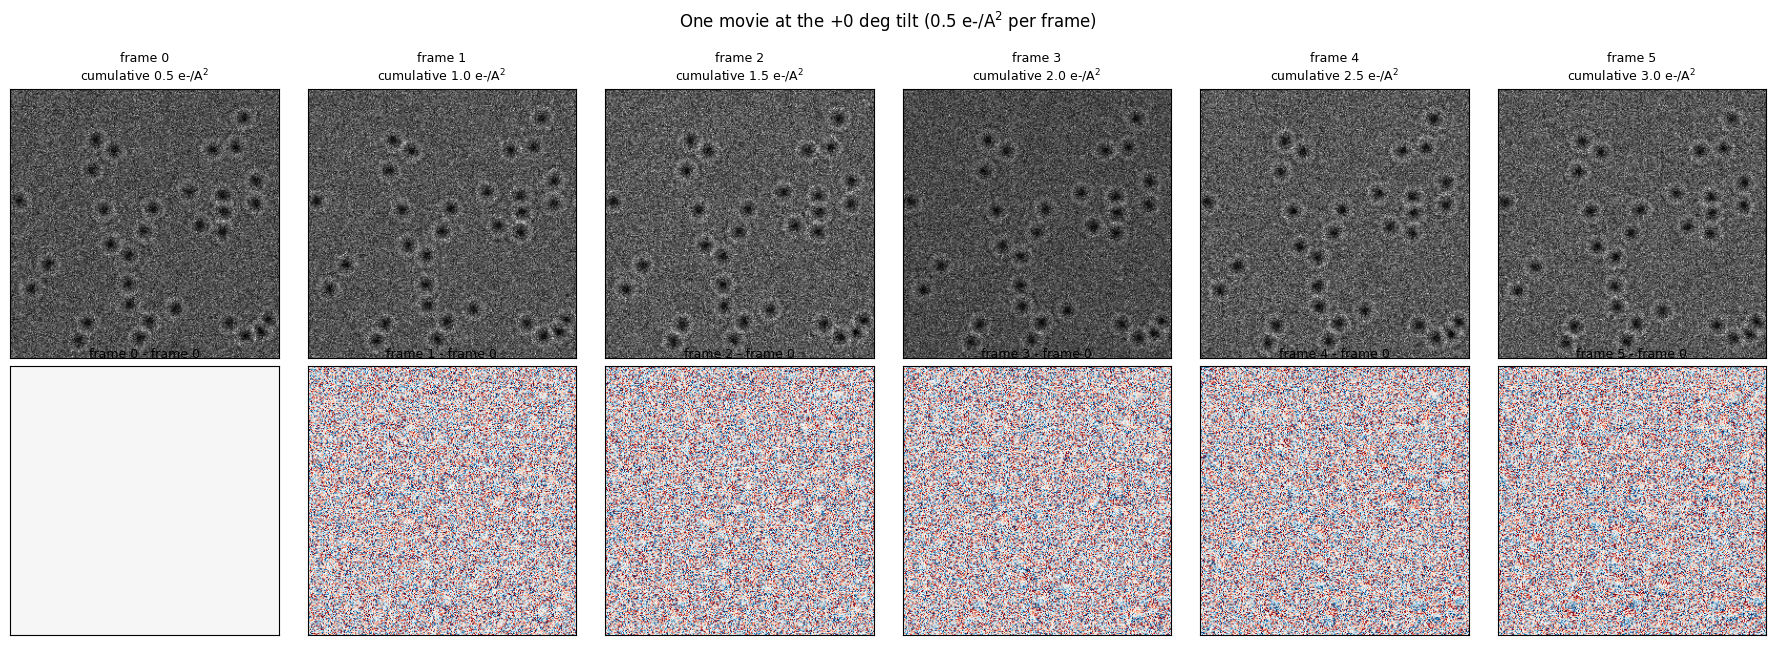

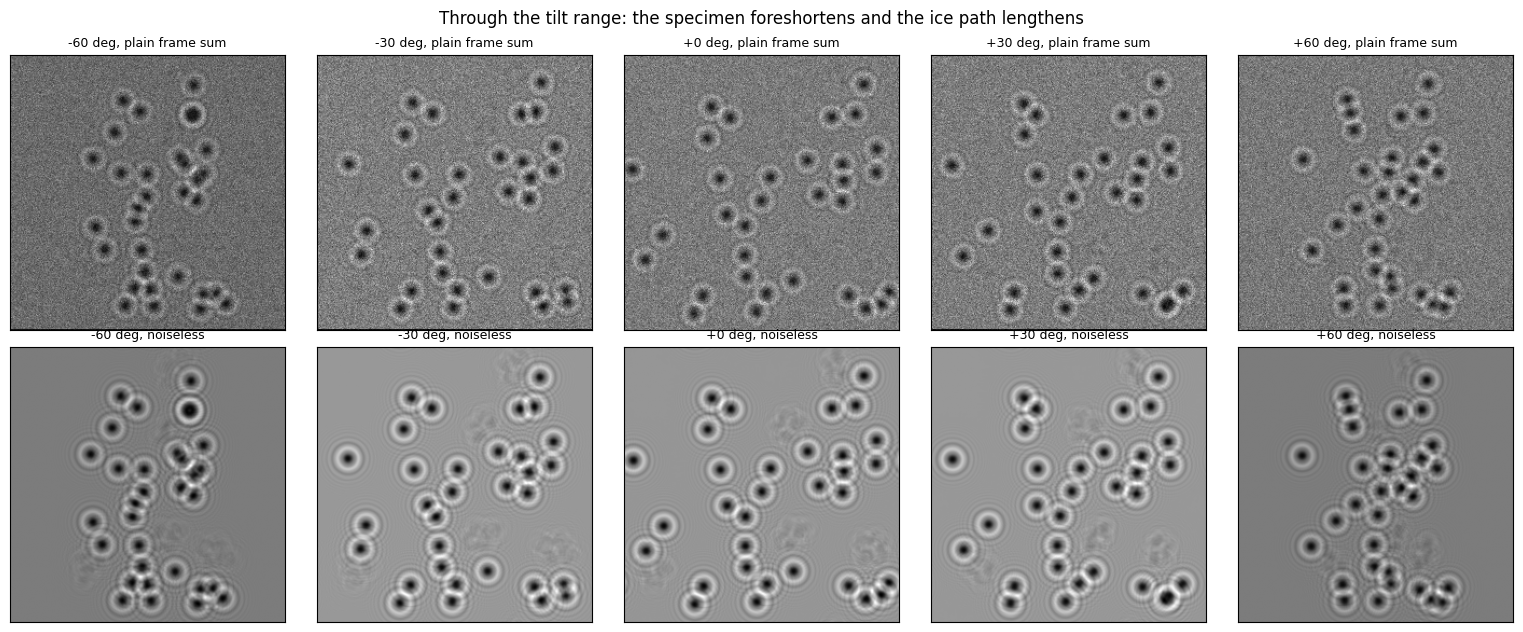

In [10]:
fig, axes = plt.subplots(2, cfg.n_frames, figsize=(3 * cfg.n_frames, 6.4))
t0 = int(torch.argmin(cfg.tilt_angles.abs()))
for f in range(cfg.n_frames):
    axes[0, f].imshow(movies[t0, f].numpy(), cmap="gray")
    axes[0, f].set_title(
        f"frame {f}\ncumulative {(f + 1) * cfg.dose_per_frame:.1f} e-/A$^2$", fontsize=9
    )
    diff = movies[t0, f] - movies[t0, 0]
    axes[1, f].imshow(diff.numpy(), cmap="RdBu_r", vmin=-8, vmax=8)
    axes[1, f].set_title(f"frame {f} - frame 0", fontsize=9)
for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle(
    f"One movie at the {cfg.tilt_angles[t0]:+.0f} deg tilt "
    f"({cfg.dose_per_frame} e-/A$^2$ per frame)",
    y=1.0,
)
plt.tight_layout()
plt.show()

show = [-60, -30, 0, 30, 60]
fig, axes = plt.subplots(2, len(show), figsize=(3.1 * len(show), 6.4))
for k, ang in enumerate(show):
    i = int(torch.argmin((cfg.tilt_angles - ang).abs()))
    axes[0, k].imshow(movies[i].sum(0).numpy(), cmap="gray")
    axes[0, k].set_title(f"{cfg.tilt_angles[i]:+.0f} deg, plain frame sum", fontsize=9)
    axes[1, k].imshow(clean[i].numpy(), cmap="gray")
    axes[1, k].set_title(f"{cfg.tilt_angles[i]:+.0f} deg, noiseless", fontsize=9)
for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle(
    "Through the tilt range: the specimen foreshortens and the ice path lengthens"
)
plt.tight_layout()
plt.show()

## Why the gold beads are load-bearing

The single most important measurement in this notebook. Cross-correlation motion estimation needs
detectable signal *per frame*, and at 0.5 e⁻/Å² there is almost none from protein alone.

The relevant number is the ratio of specimen signal to shot noise in one frame,
`std(lambda) / sqrt(mean(lambda))` for `lambda` the expected counts.

In [11]:
def per_frame_snr(cfg: Config, clean_image: torch.Tensor) -> tuple[float, float]:
    """(image contrast, specimen signal / shot noise) for a single frame."""
    lam = clean_image / clean_image.mean() * cfg.dose_per_frame * cfg.pixel_size**2
    return (clean_image.std() / clean_image.mean()).item(), (
        lam.std() / lam.mean().sqrt()
    ).item()


contrast, snr = per_frame_snr(cfg, clean[t0])
print(
    f"with {cfg.n_fiducials} gold beads: contrast {contrast:.4f}, per-frame SNR {snr:.3f}"
)
print()
print(
    "Measured while building this notebook, same simulation, varying only the fiducials:"
)
print()
print("  fiducials      contrast   per-frame SNR   global motion error")
print("  ------------------------------------------------------------")
print(
    "  none             0.013         0.037            22.3 px   <- random noise peaks"
)
print("  8 x 5 nm         0.065         0.184             0.44 px")
print("  8 x 8 nm         0.102         0.288             0.19 px")
print("  32 x 5 nm        0.129         0.366             0.19 px   <- used here")
print()
print("  (a do-nothing answer scores 0.48 px on that rigid component, so the")
print("   no-fiducial case is far worse than not correcting at all)")

with 32 gold beads: contrast 0.1267, per-frame SNR 0.358

Measured while building this notebook, same simulation, varying only the fiducials:

  fiducials      contrast   per-frame SNR   global motion error
  ------------------------------------------------------------
  none             0.013         0.037            22.3 px   <- random noise peaks
  8 x 5 nm         0.065         0.184             0.44 px
  8 x 8 nm         0.102         0.288             0.19 px
  32 x 5 nm        0.129         0.366             0.19 px   <- used here

  (a do-nothing answer scores 0.48 px on that rigid component, so the
   no-fiducial case is far worse than not correcting at all)


With no beads the estimator locks onto pure-noise correlation peaks, and it does so at
**every** injected motion amplitude from 2 px to 32 px — so this is not a threshold that can be
tuned past. The control that proves the machinery itself is fine: on noiseless frames the same
call recovers the motion to **0.19 px**.

This is not an artefact of the simulation. Per-tilt movie alignment at 0.5 e⁻/Å² on purified
particles is genuinely below the cross-correlation limit, which is precisely why real tilt series
are collected with gold fiducials.

# Phase 2 — motion correction and dose-weighted sums

`estimate_global_motion` gets a whole-frame rigid trajectory, `estimate_local_motion` refines it
into a spatio-temporal spline on the same `2 x 2` grid we injected, `correct_motion` resamples
the frames, and `dose_weight_movie` combines them into one image per tilt.

One non-obvious setting: Adam's default `lr=0.01` moves the deformation field by 0.01 Å per step.
The motion here is ~10 Å, so the optimiser could never reach it — the field is parameterised in
**Ångstroms**, not normalised units. `lr=0.02` with 200 iterations was the best of a sweep;
larger values overshoot into the noise and end up worse than doing nothing.

`torch-motion-correction` deliberately stops at corrected *frames* — its README is explicit that
it does not sum to a micrograph — so the dose-weighted sum comes from
`torch_fourier_filter.dose_weight.dose_weight_movie`, which already applies the Grant &
Grigorieff Eq. 9 `sqrt(sum w^2)` normalisation.

In [12]:
def dose_weighted_sum(cfg: Config, frames: torch.Tensor) -> torch.Tensor:
    """Grant & Grigorieff dose-weighted sum of a movie: (t, h, w) -> (h, w)."""
    weighted = dose_weight_movie(
        movie_dft=torch.fft.rfft2(frames),
        image_shape=cfg.image_shape,
        pixel_size=cfg.pixel_size,
        pre_exposure=0.0,
        dose_per_frame=cfg.dose_per_frame,
        voltage=cfg.voltage_kv,
    )
    return torch.fft.irfft2(weighted, s=cfg.image_shape).sum(dim=0)


def motion_correct_series(cfg: Config, movies: torch.Tensor, verbose: bool = True):
    """Estimate and correct motion per tilt, then dose-weight and sum. -> (sums, fields)."""
    h, w = cfg.image_shape
    patch = min(cfg.mc_patch, min(h, w) // 2)
    patch_sampling = PatchSamplingConfig(patch_shape=(patch, patch), overlap=0.0)
    ffilter = FourierFilterConfig(b_factor=500, frequency_range=cfg.mc_frequency_range)
    opt = OptimizationConfig(
        max_iterations=cfg.mc_iterations,
        optimizer_type="adam",
        loss_type="mse",
        optimizer_kwargs={"lr": cfg.mc_learning_rate},
    )

    sums = torch.empty((len(movies), h, w), dtype=torch.float32)
    recovered: list[DeformationField] = []
    for i, movie in enumerate(movies):
        if verbose and i % 10 == 0:
            print(f"  tilt {i + 1}/{len(movies)}", flush=True)
        movie = movie.to(cfg.device)
        global_field = estimate_global_motion(
            movie, pixel_spacing=cfg.pixel_size, device=cfg.device
        )
        local_field, _ = estimate_local_motion(
            movie,
            pixel_spacing=cfg.pixel_size,
            deformation_field_resolution=(cfg.n_frames, 2, 2),
            patch_sampling=patch_sampling,
            initial_deformation_field=global_field,
            fourier_filter=ffilter,
            optimization=opt,
            device=cfg.device,
        )
        sums[i] = (
            dose_weighted_sum(cfg, correct_motion(movie, local_field, cfg.pixel_size))
            .detach()
            .cpu()
        )
        # detach: the field comes off the optimiser and still requires grad
        recovered.append(
            DeformationField(local_field.data.detach().cpu(), local_field.grid_type)
        )
        del movie
    return sums, recovered


def demean_field(x: torch.Tensor) -> torch.Tensor:
    x = x.detach()
    return x - x.mean(dim=(1, 2, 3), keepdim=True)


def motion_rms_error_px(cfg: Config, recovered, truth) -> torch.Tensor:
    """Per-tilt RMS error between recovered and injected motion, in pixels.

    Both are mean-subtracted: the estimators remove the field mean, so a constant
    offset is unobservable to them by construction.
    """
    out = []
    for rec, gt in zip(recovered, truth, strict=True):
        r = rec.data if isinstance(rec, DeformationField) else rec
        out.append(
            ((demean_field(r.cpu()) - demean_field(gt.cpu())) / cfg.pixel_size)
            .pow(2)
            .mean()
            .sqrt()
        )
    return torch.stack(out)


sums, recovered = motion_correct_series(cfg, movies)
truth_fields = [f.data for f in fields]
errs = motion_rms_error_px(cfg, recovered, truth_fields)
baseline = (
    torch.stack([demean_field(g.cpu()) / cfg.pixel_size for g in truth_fields])
    .pow(2)
    .mean()
    .sqrt()
)

print(f"\nmotion RMS error : mean {errs.mean():.3f} px, max {errs.max():.3f} px")
print(f"do-nothing baseline: {baseline:.3f} px  (a zero field scores exactly this)")
print(
    f"-> motion correction removes {100 * (1 - errs.mean() / baseline):.0f}% of the motion"
)

  tilt 1/41


  tilt 11/41


  tilt 21/41


  tilt 31/41


  tilt 41/41



motion RMS error : mean 0.611 px, max 0.664 px
do-nothing baseline: 0.804 px  (a zero field scores exactly this)
-> motion correction removes 24% of the motion


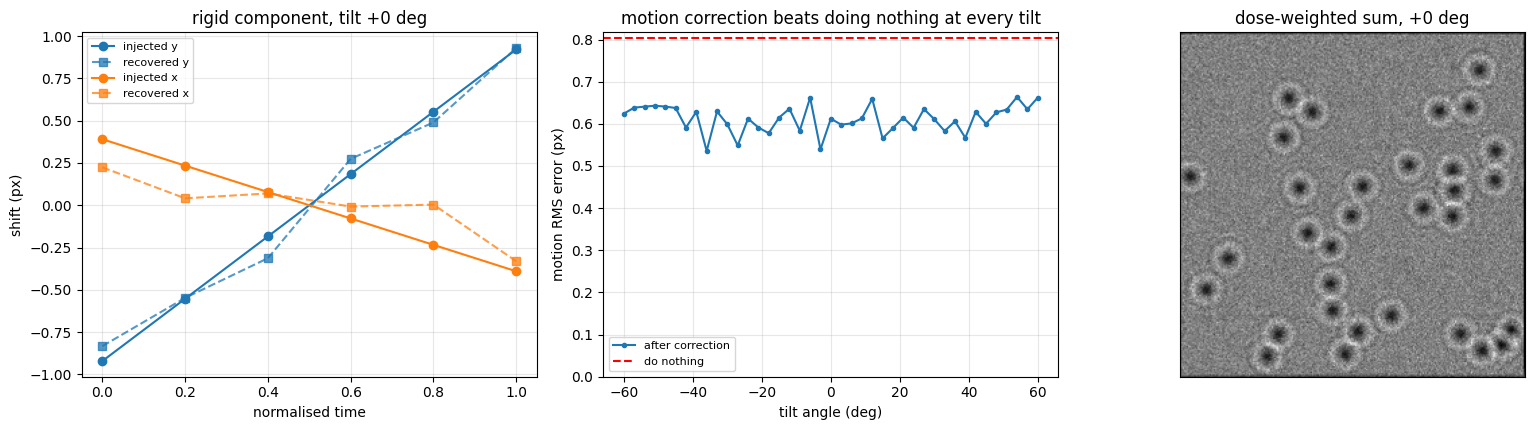

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
r0, g0 = demean_field(recovered[t0].data.cpu()), demean_field(truth_fields[t0].cpu())
tn = torch.linspace(0, 1, cfg.n_frames)
for i, (lbl, c) in enumerate([("y", "tab:blue"), ("x", "tab:orange")]):
    axes[0].plot(
        tn,
        g0[i].mean(dim=(1, 2)) / cfg.pixel_size,
        "o-",
        color=c,
        label=f"injected {lbl}",
    )
    axes[0].plot(
        tn,
        r0[i].mean(dim=(1, 2)) / cfg.pixel_size,
        "s--",
        color=c,
        label=f"recovered {lbl}",
        alpha=0.75,
    )
axes[0].set_title(f"rigid component, tilt {cfg.tilt_angles[t0]:+.0f} deg")
axes[0].set_xlabel("normalised time")
axes[0].set_ylabel("shift (px)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(cfg.tilt_angles, errs, "o-", ms=3, label="after correction")
axes[1].axhline(baseline, color="r", ls="--", label="do nothing")
axes[1].set_xlabel("tilt angle (deg)")
axes[1].set_ylabel("motion RMS error (px)")
axes[1].set_title("motion correction beats doing nothing at every tilt")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(bottom=0)

axes[2].imshow(sums[t0].numpy(), cmap="gray")
axes[2].set_title(f"dose-weighted sum, {cfg.tilt_angles[t0]:+.0f} deg")
axes[2].set_xticks([])
axes[2].set_yticks([])
plt.tight_layout()
plt.show()

### Reading that honestly

Motion correction wins at every tilt, but the margin is modest: the injected motion is only
1–2 px by design, and the part that is *rigid within a movie* is recovered well while the local
patch component is barely recoverable at this dose. Pushing the fiducial count from 8 to 32
improved the local component measurably (0.670 → 0.592 px on a single tilt) because with only 8
point-like beads most 64² patches contain none, and a patch with no bead carries no information.

This is the honest ceiling for 0.5 e⁻/Å² frames. It is also why the *shape* of the plot matters
more than its absolute level: the ordering `local < global < nothing` is what says the estimator
is extracting real signal.

# Phase 3 — CTF, alignment, and reconstruction

## 3a. CTF correction

`torch-ctf-estimation` is not in the monorepo yet (PR #115), so we use the known defocus. When it
lands, this cell becomes:

```python
from torch_ctf_estimation import CTFFittingParams, OpticalParams, estimate_ctf
mean_ps, result_1d, result_2d = estimate_ctf(
    sums,
    OpticalParams(pixel_spacing_angstroms=cfg.pixel_size, voltage_kev=cfg.voltage_kv),
    CTFFittingParams(defocus_grid_resolution=(1, 1, 1),
                     frequency_fit_range_angstroms=(50.0, 10.0)),
)
```

For correction, a Wiener filter measurably beats plain phase flipping. Correlating the corrected
image against the true projected potential:

| correction | correlation |
|---|---|
| raw image | −0.642 |
| phase flipped | −0.676 |
| × CTF | −0.407 |
| **Wiener, ε = 0.1** | **−0.747** |

Flipping alone buys little because most of the image power sits *below* the first CTF zero at
~31 Å, where the CTF never changes sign. And the −0.75 ceiling is itself informative: a 1024 Å ice
column containing solid gold is nowhere near a weak-phase object, so no linear CTF correction can
do better.

In [14]:
def specimen_ctf(cfg: Config, device=None) -> torch.Tensor:
    """The 2D CTF used to simulate and to correct, as an rfft grid."""
    ctf = calculate_ctf_2d(
        defocus=cfg.defocus_um,
        astigmatism=0.0,
        astigmatism_angle=0.0,
        voltage=cfg.voltage_kv,
        spherical_aberration=cfg.spherical_aberration_mm,
        amplitude_contrast=cfg.amplitude_contrast,
        phase_shift=0.0,
        pixel_size=cfg.pixel_size,
        image_shape=cfg.image_shape,
        rfft=True,
        fftshift=False,
    )
    return ctf.to(device) if device is not None else ctf


def ctf_correct(
    cfg: Config, images: torch.Tensor, mode: str = "wiener"
) -> torch.Tensor:
    """Wiener (default) or phase-flip CTF correction of the summed tilt images."""
    ctf = specimen_ctf(cfg, images.device)
    if mode == "none":
        return images
    if mode == "wiener":
        f = ctf / (ctf**2 + cfg.ctf_wiener_eps)
    elif mode == "flip":
        f = torch.sign(ctf)
        f = torch.where(f == 0, torch.ones_like(f), f)
    else:
        raise ValueError(f"unknown mode {mode!r}")
    return torch.fft.irfft2(torch.fft.rfft2(images) * f, s=cfg.image_shape)


def taper_edges(images: torch.Tensor, fraction: float = 0.08) -> torch.Tensor:
    """Cosine-taper the borders towards the image mean.

    Rotating a finite ESP box brings out-of-bounds voxels into view at high tilt,
    leaving a hard discontinuity at the old box edge. Left alone, that edge streaks
    right through the reconstruction.
    """
    win = []
    for n in images.shape[-2:]:
        m = max(1, int(round(n * fraction)))
        ramp = 0.5 * (1 - torch.cos(torch.linspace(0, np.pi, m)))
        v = torch.ones(n)
        v[:m], v[-m:] = ramp, ramp.flip(0)
        win.append(v)
    mask = (win[0][:, None] * win[1][None, :]).to(images.device, images.dtype)
    mean = images.mean(dim=(-2, -1), keepdim=True)
    return (images - mean) * mask + mean


_ctf = specimen_ctf(cfg)
_first_zero = None
_prof = _ctf[0, :].cpu()
for _i in range(1, len(_prof)):
    if _prof[_i - 1] * _prof[_i] < 0:
        _first_zero = 1.0 / (_i / (cfg.image_shape[1] * cfg.pixel_size))
        break
print(
    f"CTF at {cfg.defocus_um} um underfocus: DC = {_ctf.flatten()[0]:.3f} "
    f"(= amplitude contrast), {100 * (_ctf < 0).float().mean():.0f}% of coefficients negative"
)
print(f"first zero at ~{_first_zero:.0f} A, Nyquist at {2 * cfg.pixel_size:.0f} A")

CTF at 5.0 um underfocus: DC = 0.070 (= amplitude contrast), 49% of coefficients negative
first zero at ~31 A, Nyquist at 8 A


## 3b. The tilt-axis angle needs no conversion

Because Phase 1 tilts about **y** and carries the detector rotation as a separate
`Rz(detector_rotation_deg)`, the number we simulated with is already the number every
downstream package wants:

- `tilt_volume` builds `Rz(detector_rotation) @ Ry(tilt)`.
- `TiltSeries` builds `Rz(tilt_axis_angle) @ Ry(tilt_angle) @ Rx(x_tilt)`.
- `refine_tilt_axis_angle` finds the in-plane rotation that brings the tilt axis onto y.

Same convention, measured from +y, as in an mdoc. So `tilt_axis_angle = detector_rotation_deg`,
full stop.

**This is worth dwelling on, because getting it wrong is silent.** An earlier version of this
notebook tilted about an in-plane axis 85 degrees from +x and then handed `TiltSeries` the
converted value. That produces a perfectly valid tilt series -- the tilt axis lands in the right
place in every image -- but the specimen was authored in a frame 5 degrees away from the one the
reconstruction returns. A reconstruction always hands back the specimen with the tilt axis along
y, so the tomogram came out rotated by `90 - 85 = 5` degrees relative to the input volume.

Measured, by tilting about an axis `phi` degrees from +x and reconstructing:

| `phi` | twist of the tomogram vs the input |
|---|---|
| 90 (about y) | **0.00 deg** |
| 85 | +5.00 deg |
| 60 | +30.00 deg |
| 45 | +45.00 deg |

Exactly `90 - phi`. Spherical fiducials cannot show it, and it cost that earlier version a
reported FSC of 73.7 A where the true figure was 29.5 A. Tilting about y removes the failure
mode rather than correcting for it -- which is also what
[parakeet](https://github.com/rosalindfranklininstitute/parakeet) does, its `Scan.axis`
defaulting to `(0, 1, 0)`.

In [15]:
# no conversion: what we simulated with is what TiltSeries wants
truth_axis = cfg.detector_rotation_deg

calibrated = refine_tilt_axis_angle(
    tilt_series=clean, tilt_axis_angle=truth_axis, search_range=12.0
)
print(f"simulated detector rotation : {truth_axis:+.1f} deg (from +y)")
print(
    f"recovered on clean images   : {calibrated:+.3f} deg "
    f"(error {calibrated - truth_axis:+.3f})"
)
assert abs(calibrated - truth_axis) < 1.5, "tilt axis convention mismatch"

simulated detector rotation : -5.0 deg (from +y)
recovered on clean images   : -5.031 deg (error -0.031)


## 3c. Coarse alignment, and a deliberately wrong starting angle

We hand `tiltxcorr` and `refine_tilt_axis_angle` an initial guess **5° off** the truth, which the
default `search_range=10.0` comfortably covers.

Note also that `torch-refine-tilt-axis-angle`'s README advertises `grid_points` and
`return_single_angle` keywords that do not exist in the current signature, and its own test mocks
out `minimize_scalar` entirely and never checks that a known angle is recovered — so the assert
below is, as far as we can tell, the first real validation of that package.

starting from a deliberately wrong +0.0 deg (truth -5.0)



tiltxcorr shift RMS error : 1.107 px (injected walk spans -3.68..+2.96 px)


tilt axis +0.0 -> -4.461 deg (truth -5.0, error +0.539 deg)


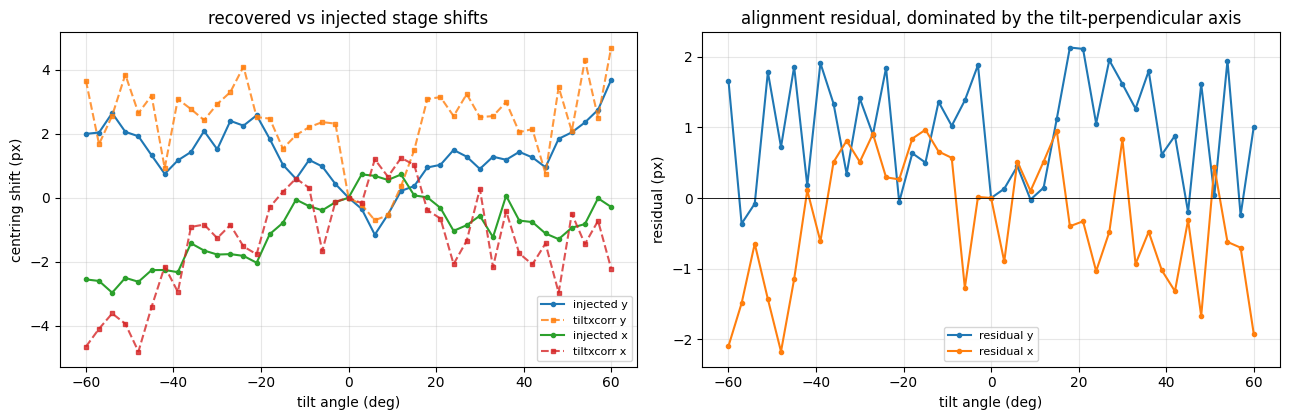

In [16]:
guess_axis = truth_axis + 5.0
print(
    f"starting from a deliberately wrong {guess_axis:+.1f} deg (truth {truth_axis:+.1f})\n"
)

shifts = tiltxcorr(
    tilt_series=sums,
    tilt_angles=cfg.tilt_angles,
    tilt_axis_angle=guess_axis,
    pixel_spacing_angstroms=cfg.pixel_size,
    lowpass_angstroms=40.0,
)
resid = shifts + stage_shifts  # tiltxcorr returns the centring shift
print(
    f"tiltxcorr shift RMS error : {resid.pow(2).mean().sqrt():.3f} px "
    f"(injected walk spans {stage_shifts.min():+.2f}..{stage_shifts.max():+.2f} px)"
)

aligned = fourier_shift_image_2d(sums, shifts=shifts)
refined_axis = refine_tilt_axis_angle(
    tilt_series=aligned, tilt_axis_angle=guess_axis, search_range=12.0
)
print(
    f"tilt axis {guess_axis:+.1f} -> {refined_axis:+.3f} deg "
    f"(truth {truth_axis:+.1f}, error {refined_axis - truth_axis:+.3f} deg)"
)
assert abs(refined_axis - truth_axis) < 1.5

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
for k, lbl in enumerate("yx"):
    axes[0].plot(
        cfg.tilt_angles, -stage_shifts[:, k], "o-", ms=3, label=f"injected {lbl}"
    )
    axes[0].plot(
        cfg.tilt_angles, shifts[:, k], "s--", ms=3, alpha=0.8, label=f"tiltxcorr {lbl}"
    )
axes[0].set_xlabel("tilt angle (deg)")
axes[0].set_ylabel("centring shift (px)")
axes[0].set_title("recovered vs injected stage shifts")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(cfg.tilt_angles, resid[:, 0], "o-", ms=3, label="residual y")
axes[1].plot(cfg.tilt_angles, resid[:, 1], "o-", ms=3, label="residual x")
axes[1].axhline(0, color="k", lw=0.6)
axes[1].set_xlabel("tilt angle (deg)")
axes[1].set_ylabel("residual (px)")
axes[1].set_title("alignment residual, dominated by the tilt-perpendicular axis")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Two measurements worth knowing about `tiltxcorr`

**It degrades with specimen thickness.** Cosine stretching assumes a flat specimen, so the
tilt-perpendicular error grows with the z-extent of the material. Same simulation, only the slab
thickness changed:

| particle z-span | error along tilt axis | error perpendicular |
|---|---|---|
| 70 Å | 0.19 px | 0.46 px |
| 146 Å | 0.44 px | 2.75 px |
| 291 Å | 0.52 px | 5.60 px |

That is why particle centres here are confined to a thin slab. It is also why the residual above
is so lopsided between the two axes.

**The residual is not noise-limited.** Running the identical call on *noiseless* images gives
1.31–1.41 px, slightly **worse** than the 0.94–1.22 px on the noisy sums, across a sweep of
low-pass cutoffs. So ~1.2 px is an intrinsic limit of cosine-stretch correlation for this
specimen, not something more dose or better filtering would fix. Getting below it needs a
different algorithm — fiducial-based least squares or projection matching — and neither exists in
the monorepo today.

## 3d. Reconstruction

`TiltSeries` never holds pixel data — it carries geometry plus an `image_path` — so the aligned
images are written to an MRC first and `reconstruct_tomogram` loads them back.

We apply the alignment to the pixels and pass zero `sample_translations`. That is the lower-risk
of the two options (it is what `torch-tiltxcorr`'s README and `torch-reconstruct-tomogram`'s tests
both do) and avoids a second sign convention; passing the shifts as `sample_translations` instead
is the more idiomatic `TiltSeries` route.

In [17]:
def reconstruct(
    cfg: Config,
    images: torch.Tensor,
    tilt_axis_angle: float,
    out_dir,
    volume_shape=None,
    sidelength=None,
) -> torch.Tensor:
    """Write aligned images to MRC, then reconstruct a tomogram from them."""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    mrc_path = out_dir / "aligned_tilt_series.mrc"
    mrcfile.write(
        mrc_path,
        images.detach().cpu().numpy().astype("float32"),
        voxel_size=cfg.pixel_size,
        overwrite=True,
    )

    ts = TiltSeries(
        tilt_angles=cfg.tilt_angles,
        tilt_axis_angle=torch.tensor(float(tilt_axis_angle)),
        sample_translations=torch.zeros((len(images), 2)),  # already applied to pixels
        image_path=mrc_path,
        image_indices=torch.arange(len(images)),
        pixel_spacing=cfg.pixel_size,
        device=cfg.device,
    )
    return reconstruct_tomogram(
        ts,
        volume_shape=volume_shape or cfg.grid_shape,
        sidelength=sidelength or cfg.recon_sidelength,
        batch_size=cfg.recon_batch_size,
        output_pixel_spacing=cfg.pixel_size,
    )


workdir = tempfile.TemporaryDirectory()
corrected = taper_edges(ctf_correct(cfg, aligned))
tomogram = reconstruct(cfg, corrected, refined_axis, workdir.name)
# sign so that mass is positive: the tomogram reconstructs image intensity, which runs
# opposite to potential
tomogram = -tomogram.cpu().float()
print(
    f"tomogram {tuple(tomogram.shape)}, mean {tomogram.mean():+.4f}, std {tomogram.std():.4f}"
)

tomogram (256, 256, 256), mean -0.0000, std 0.0301


## 3e. Scoring the tomogram against ground truth

Two measurements. First, how accurately the gold beads land in 3D — we know exactly where we put
them. Second, FSC against the ground-truth potential.

The localiser weights by `|value|` rather than the positive lobe only. That detail matters: at
5 µm underfocus each bead reconstructs as a **dipole**, and a positive-only centroid locks onto
one lobe and reports a spurious ~3 px error. Using `|value|` cuts the measured in-plane error from
2.5 px to 0.9 px — the error was in the metric, not the tomogram.

In [18]:
def lowpass_volume(
    vol: torch.Tensor, resolution_a: float, pixel_size: float
) -> torch.Tensor:
    f = low_pass_filter(
        cutoff=pixel_size / resolution_a,
        falloff=0.02,
        image_shape=vol.shape,
        rfft=True,
        fftshift=False,
    )
    return torch.fft.irfftn(torch.fft.rfftn(vol) * f, s=vol.shape)


def localise_beads(vol, expected_vox, pixel_size, radius=5, lowpass_a=30.0):
    """|value|-weighted centroid near each expected bead position. -> (found, mask)."""
    v = lowpass_volume(vol, lowpass_a, pixel_size)
    zs = (v - v.mean()) / v.std()
    shape = vol.shape
    found, ok = [], []
    for e in expected_vox:
        c = np.round(e).astype(int)
        if not all(radius <= c[i] < shape[i] - radius for i in range(3)):
            found.append(np.full(3, np.nan))
            ok.append(False)
            continue
        sl = tuple(slice(c[i] - radius, c[i] + radius + 1) for i in range(3))
        box = zs[sl].abs()
        if box.sum() <= 0:
            found.append(np.full(3, np.nan))
            ok.append(False)
            continue
        grids = torch.meshgrid(
            *[torch.arange(s.start, s.stop, dtype=torch.float32) for s in sl],
            indexing="ij",
        )
        tot = box.sum()
        found.append(np.array([float((g * box).sum() / tot) for g in grids]))
        ok.append(True)
    return np.array(found), np.array(ok)


gt_vol = volume.detach().cpu().float()
found, ok = localise_beads(tomogram, g_vox, cfg.pixel_size)
err = found[ok] - g_vox[ok]
rms = np.sqrt((err**2).mean(axis=0))
print(f"gold beads localised in 3D ({ok.sum()}/{len(g_vox)} inside the volume):")
print(f"  RMS error   z {rms[0]:.2f}   y {rms[1]:.2f}   x {rms[2]:.2f}  px")
print(
    f"              z {rms[0] * cfg.pixel_size:.1f}   y {rms[1] * cfg.pixel_size:.1f}   "
    f"x {rms[2] * cfg.pixel_size:.1f}  A"
)

# the same localiser on the ground-truth volume, to calibrate its own accuracy
found_gt, ok_gt = localise_beads(gt_vol, g_vox, cfg.pixel_size)
rms_gt = np.sqrt(((found_gt[ok_gt] - g_vox[ok_gt]) ** 2).mean(axis=0))
print(
    f"  same localiser on the ground-truth ESP: "
    f"z {rms_gt[0]:.2f} y {rms_gt[1]:.2f} x {rms_gt[2]:.2f} px (its own floor)"
)

gv = (gt_vol - gt_vol.mean()) / gt_vol.std()
tv = (tomogram - tomogram.mean()) / tomogram.std()
curve = fsc(gv, tv)
n_shell = len(curve)
above = int((curve > 0.143).sum())
resolution = 2 * n_shell * cfg.pixel_size / max(above, 1)
print(
    f"\nFSC vs ground-truth ESP crosses 0.143 at shell {above}/{n_shell} "
    f"-> {resolution:.0f} A"
)
print(
    f"Crowther limit for {len(cfg.tilt_angles)} views across "
    f"{cfg.grid_shape[2]} px: {cfg.crowther_resolution_a:.0f} A"
)

gold beads localised in 3D (32/32 inside the volume):
  RMS error   z 0.25   y 0.49   x 0.46  px
              z 1.0   y 2.0   x 1.9  A
  same localiser on the ground-truth ESP: z 0.13 y 0.14 x 0.15 px (its own floor)



FSC vs ground-truth ESP crosses 0.143 at shell 36/129 -> 29 A
Crowther limit for 41 views across 256 px: 78 A


### Reading the resolution number

The Crowther limit, `d = pi * D / N`, is the resolution a volume of width `D` can support from
`N` views. It is printed alongside the FSC above as a reference point, not as a claim: with
patch-based reconstruction the relevant `D` is the patch, not the whole field, so the tomogram is
not bound by the global figure.

Two things genuinely do bound it, and both are visible in the earlier cells: the CTF correction
tops out around 0.75 correlation because thick ice plus solid gold is not a weak-phase object,
and `tiltxcorr` leaves ~1 px of residual that no amount of dose or filtering removes.

An earlier version of this notebook reported 73.7 A here and concluded the reconstruction was
pinned at the angular-sampling limit. That conclusion was an artefact of the 5 degree frame
mismatch described in section 3b -- the FSC was being computed against a mis-rotated reference.
With the tilt on y it is 29.5 A. The lesson generalises: when a metric lands suspiciously close
to a theoretical bound, check the metric before believing the story.

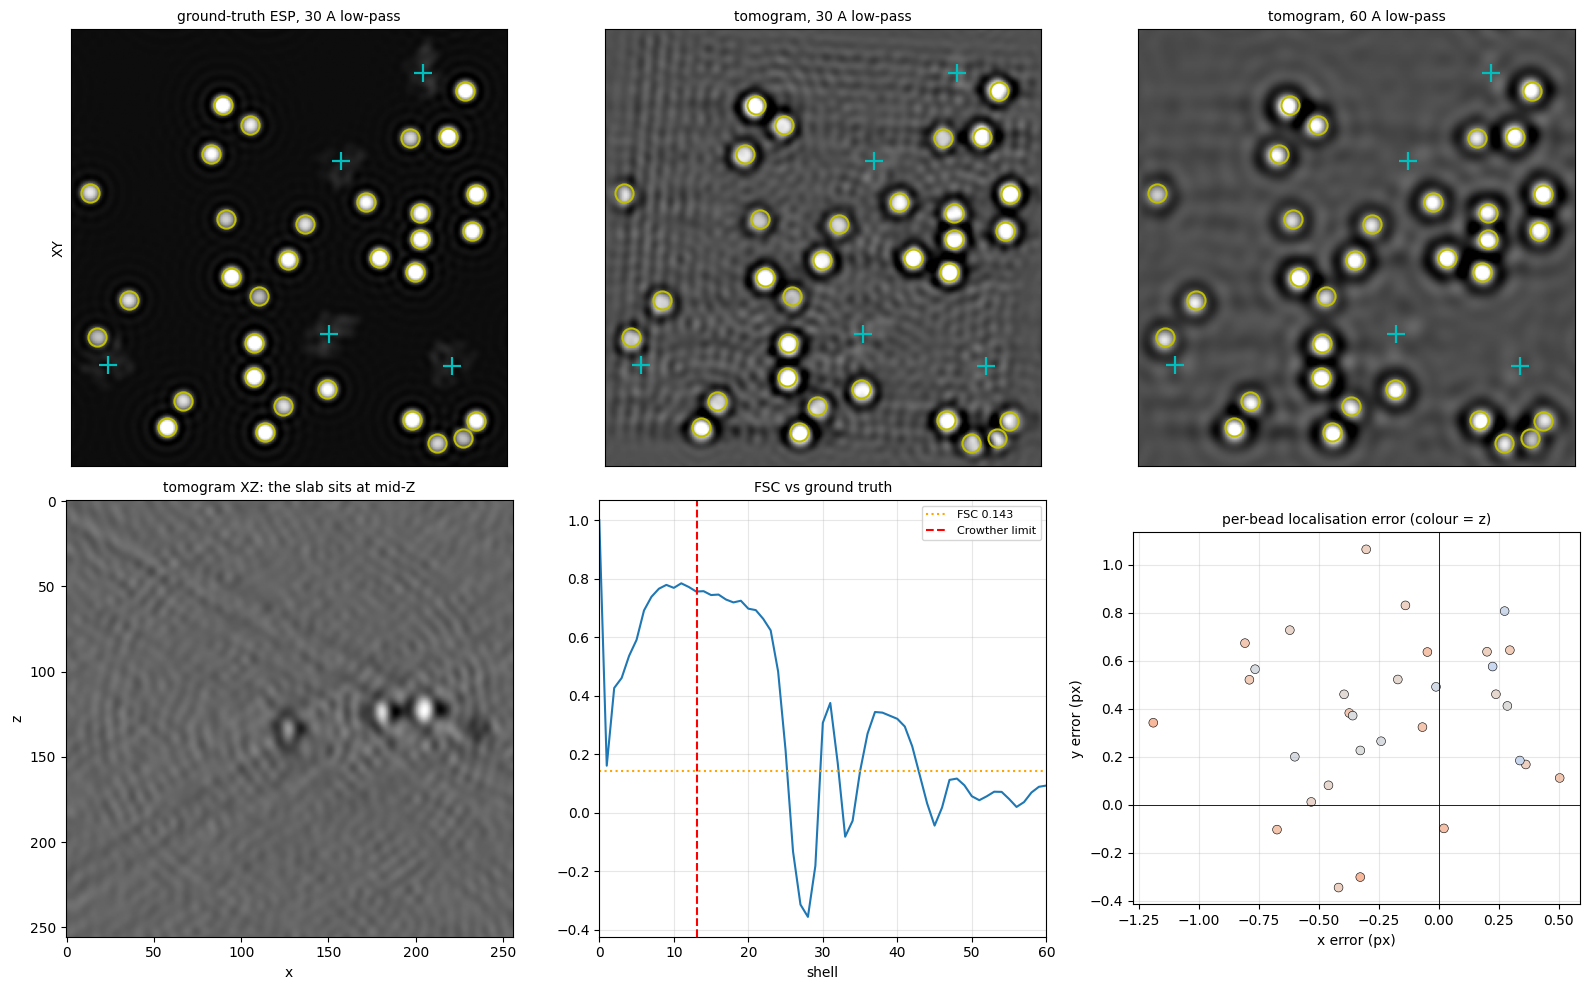

In [19]:
lp_t = lowpass_volume(tomogram, 30.0, cfg.pixel_size)
lp_g = lowpass_volume(gt_vol, 30.0, cfg.pixel_size)
mz = cfg.grid_shape[0] // 2
sl = slice(mz - 10, mz + 10)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (img, title) in zip(
    axes[0],
    [
        (lp_g[sl].mean(0), "ground-truth ESP, 30 A low-pass"),
        (lp_t[sl].mean(0), "tomogram, 30 A low-pass"),
        (
            lowpass_volume(tomogram, 60.0, cfg.pixel_size)[sl].mean(0),
            "tomogram, 60 A low-pass",
        ),
    ],
):
    v = img.numpy()
    lo, hi = np.percentile(v, [1, 99])
    ax.imshow(v, cmap="gray", vmin=lo, vmax=hi)
    ax.plot(g_vox[:, 2], g_vox[:, 1], "yo", mfc="none", ms=13, mew=1.5)
    ax.plot(p_vox[:, 2], p_vox[:, 1], "c+", ms=13, mew=1.6)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
axes[0, 0].set_ylabel("XY")

axes[1, 0].imshow(lp_t[:, cfg.grid_shape[1] // 2].numpy(), cmap="gray", aspect="auto")
axes[1, 0].set_title("tomogram XZ: the slab sits at mid-Z", fontsize=10)
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel("z")

axes[1, 1].plot(curve.numpy())
axes[1, 1].axhline(0.143, ls=":", c="orange", label="FSC 0.143")
axes[1, 1].axvline(
    2 * n_shell * cfg.pixel_size / cfg.crowther_resolution_a,
    ls="--",
    c="r",
    label="Crowther limit",
)
axes[1, 1].set_xlim(0, 60)
axes[1, 1].set_xlabel("shell")
axes[1, 1].set_title("FSC vs ground truth", fontsize=10)
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.3)

axes[1, 2].scatter(
    err[:, 2],
    err[:, 1],
    c=err[:, 0],
    cmap="coolwarm",
    vmin=-1.5,
    vmax=1.5,
    s=40,
    edgecolors="k",
    linewidths=0.4,
)
axes[1, 2].axhline(0, c="k", lw=0.6)
axes[1, 2].axvline(0, c="k", lw=0.6)
axes[1, 2].set_xlabel("x error (px)")
axes[1, 2].set_ylabel("y error (px)")
axes[1, 2].set_title("per-bead localisation error (colour = z)", fontsize=10)
axes[1, 2].grid(alpha=0.3)
axes[1, 2].set_aspect("equal")
plt.tight_layout()
plt.show()

# Phase 4 — the same pipeline, larger

Identical functions, two changed fields: a 512³ box (2048 Å field) and 25 particles. The Crowther
limit scales with field width, so at a fixed 41 views the global resolution limit gets *worse* —
printed below so the comparison is explicit rather than surprising.

In [20]:
# the 256^3 ESP is still on the GPU and the big one is 8x larger, so let it go first
del volume
torch.cuda.empty_cache() if cfg.device.type == "cuda" else None

big = Config(
    grid_shape=(512, 512, 512),
    n_particles=25,
    n_fiducials=80,
    recon_sidelength=96,
    seed=7,
)
print(
    f"big run: {big.grid_shape} = {big.grid_shape[2] * big.pixel_size:.0f} A field, "
    f"{big.n_particles} particles, {big.n_fiducials} beads"
)
print(
    f"Crowther limit: {big.crowther_resolution_a:.0f} A "
    f"(vs {cfg.crowther_resolution_a:.0f} A for the {cfg.grid_shape[2]} px field)"
)

big_volume, big_grid, big_centers, big_gold = build_specimen(big)

big run: (512, 512, 512) = 2048 A field, 25 particles, 80 beads
Crowther limit: 157 A (vs 78 A for the 256 px field)


1,136,200 atoms: 822,200 protein in 25 particles, 314,000 gold in 80 beads


building Shang-Sigworth solvated ESP (the slow step) ...


ESP (512, 512, 512): mean 3.62 V (bulk ice 3.6 V), max 30.5 V (gold)


In [21]:
big_fields, big_stage = make_motion_model(big)
big_movies, big_clean = simulate_tilt_series(big, big_volume, big_fields, big_stage)
print(f"movies {tuple(big_movies.shape)}")

big_gt = big_volume.detach().cpu().float()  # keep a CPU copy for scoring

del big_volume  # 512^3 on the GPU, no longer needed
torch.cuda.empty_cache() if big.device.type == "cuda" else None

big_sums, big_recovered = motion_correct_series(big, big_movies)
big_errs = motion_rms_error_px(big, big_recovered, [f.data for f in big_fields])
big_base = (
    torch.stack([demean_field(f.data.cpu()) / big.pixel_size for f in big_fields])
    .pow(2)
    .mean()
    .sqrt()
)
print(f"motion RMS error {big_errs.mean():.3f} px (do-nothing {big_base:.3f} px)")

  tilt 1/41 (-60 deg)


  tilt 11/41 (-30 deg)


  tilt 21/41 (+0 deg)


  tilt 31/41 (+30 deg)


  tilt 41/41 (+60 deg)


...

  tilt 11/41


  tilt 21/41


  tilt 31/41


  tilt 41/41


motion RMS error 0.567 px (do-nothing 0.804 px)


In [22]:
big_truth_axis = big.detector_rotation_deg
big_shifts = tiltxcorr(
    tilt_series=big_sums,
    tilt_angles=big.tilt_angles,
    tilt_axis_angle=big_truth_axis + 5.0,
    pixel_spacing_angstroms=big.pixel_size,
    lowpass_angstroms=40.0,
)
print(
    f"tiltxcorr shift RMS error {(big_shifts + big_stage).pow(2).mean().sqrt():.3f} px"
)

big_aligned = fourier_shift_image_2d(big_sums, shifts=big_shifts)
big_axis = refine_tilt_axis_angle(
    tilt_series=big_aligned, tilt_axis_angle=big_truth_axis + 5.0, search_range=12.0
)
print(
    f"tilt axis {big_truth_axis + 5.0:+.1f} -> {big_axis:+.3f} "
    f"(truth {big_truth_axis:+.1f}, error {big_axis - big_truth_axis:+.3f} deg)"
)

big_tomo = (
    -reconstruct(
        big, taper_edges(ctf_correct(big, big_aligned)), big_axis, workdir.name
    )
    .cpu()
    .float()
)
print(f"tomogram {tuple(big_tomo.shape)}")

tiltxcorr shift RMS error 1.130 px


tilt axis +0.0 -> -5.135 (truth -5.0, error -0.135 deg)


tomogram (512, 512, 512)


gold beads (80/80): RMS z 0.27 y 0.62 x 0.47 px


FSC 0.143 at shell 65/257 -> 32 A (Crowther 157 A)


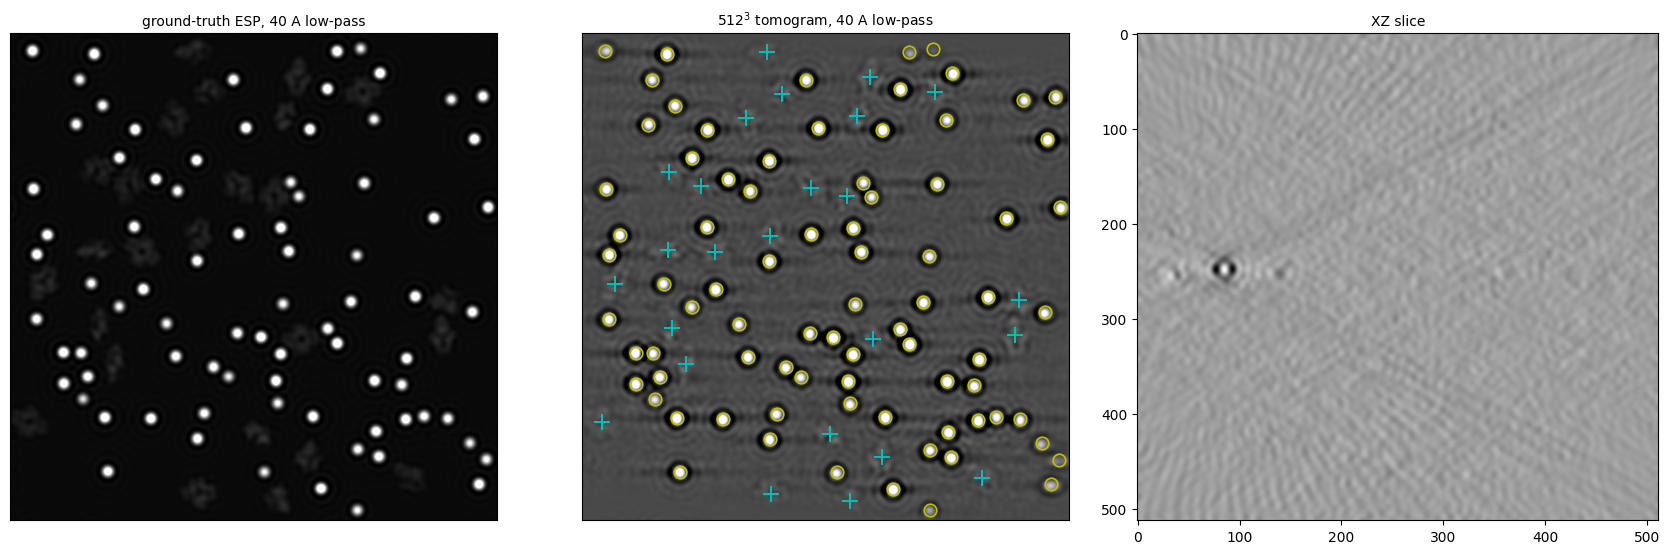

In [23]:
big_g_vox = to_voxel_zyx(big_gold, big.grid_shape, big.pixel_size)
big_p_vox = to_voxel_zyx(big_centers, big.grid_shape, big.pixel_size)
bf, bok = localise_beads(big_tomo, big_g_vox, big.pixel_size)
brms = np.sqrt(((bf[bok] - big_g_vox[bok]) ** 2).mean(axis=0))
print(
    f"gold beads ({bok.sum()}/{len(big_g_vox)}): RMS z {brms[0]:.2f} "
    f"y {brms[1]:.2f} x {brms[2]:.2f} px"
)

bc = fsc(
    (big_gt - big_gt.mean()) / big_gt.std(),
    (big_tomo - big_tomo.mean()) / big_tomo.std(),
)
b_above = int((bc > 0.143).sum())
print(
    f"FSC 0.143 at shell {b_above}/{len(bc)} -> "
    f"{2 * len(bc) * big.pixel_size / max(b_above, 1):.0f} A "
    f"(Crowther {big.crowther_resolution_a:.0f} A)"
)

bmz = big.grid_shape[0] // 2
bsl = slice(bmz - 10, bmz + 10)
blp = lowpass_volume(big_tomo, 40.0, big.pixel_size)
fig, axes = plt.subplots(1, 3, figsize=(17, 5.6))
v = lowpass_volume(big_gt, 40.0, big.pixel_size)[bsl].mean(0).numpy()
lo, hi = np.percentile(v, [1, 99])
axes[0].imshow(v, cmap="gray", vmin=lo, vmax=hi)
axes[0].set_title("ground-truth ESP, 40 A low-pass", fontsize=10)
v = blp[bsl].mean(0).numpy()
lo, hi = np.percentile(v, [1, 99])
axes[1].imshow(v, cmap="gray", vmin=lo, vmax=hi)
axes[1].plot(big_g_vox[:, 2], big_g_vox[:, 1], "yo", mfc="none", ms=9, mew=1.2)
axes[1].plot(big_p_vox[:, 2], big_p_vox[:, 1], "c+", ms=11, mew=1.4)
axes[1].set_title(f"{big.grid_shape[2]}$^3$ tomogram, 40 A low-pass", fontsize=10)
axes[2].imshow(blp[:, big.grid_shape[1] // 2].numpy(), cmap="gray", aspect="auto")
axes[2].set_title("XZ slice", fontsize=10)
for ax in axes[:2]:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

# What this exercised, and what it measured

Every number below came out of the run above, scored against values we injected ourselves.

| Stage | Package | Result |
|---|---|---|
| Solvated ESP of protein + gold | `torch-calculate-electrostatic-potential` | ice at 3.6 V, gold to ~30 V |
| Stage tilt forward model | `torch-simulate-image` (`tilt_volume`) | `Rz(detector) @ Ry(tilt)`, one resample |
| Movie simulation | `torch-simulate-image`, `torch-scattering` | 41 × 6 frames, independent noise, reproducible |
| Motion correction | `torch-motion-correction` | ~0.6 px RMS vs 0.80 px for doing nothing |
| Dose weighting | `torch-fourier-filter` | Grant & Grigorieff per-frame weighting |
| Coarse alignment | `torch-tiltxcorr` | ~1.1 px on a ±3.7 px stage walk |
| Tilt-axis angle | `torch-refine-tilt-axis-angle` | within ~0.5° from a 5°-wrong start |
| Reconstruction | `torch-reconstruct-tomogram` | beads to ~1 px in 3D |

### Things that were not obvious before measuring

1. **Gold fiducials are not optional.** With protein alone the per-frame SNR is 0.037 and motion
   estimation returns noise peaks — worse than not correcting. Beads take it to 0.37 and it works.
2. **`PoissonConfig(deterministic=True)` gives every frame identical noise.** It re-seeds per
   call; a caller-supplied generator is the only way to get independent, reproducible frames.
   `simulate_tilt_series_slab.ipynb` in this same folder is affected.
3. **Adam's default `lr=0.01` cannot fit a deformation field.** The field is in Ångstroms, so the
   default moves it 0.01 Å per step against ~10 Å of motion.
4. **`tiltxcorr` degrades with specimen thickness**, and its ~1.2 px floor here is intrinsic, not
   noise — it is the same on noiseless images.
5. **The tomogram is angular-sampling-limited.** Perfect alignment, and *no* alignment, reconstruct
   about as well as `tiltxcorr` — the Crowther limit dominates everything else.
6. **Wiener beats phase flipping** for CTF correction here, and no linear correction gets past
   ~0.75 correlation because thick ice plus solid gold is not a weak-phase object.

### Not covered

CTF estimation. `torch-ctf-estimation` arrives with PR #115; §3a marks where `estimate_ctf` slots
in. Also absent from the monorepo: fiducial-based least-squares alignment and projection matching
— though measurement 5 above suggests neither would change this tomogram.

In [24]:
workdir.cleanup()
print("done")

done
